# ChestCare pulmonary hypertension (PH): leak-free re-evaluation

Dataset: 800 chest X-rays (600 normal in RGB, 200 PH in grayscale). The 200 PH images are only **22 original source images plus 178 augmented copies**.

**What this notebook does (same pipeline as the TB, cardiomegaly and pneumonia notebooks, plus three PH-specific safeguards)**
- **Splits by source image.** Augmented copies are linked to their source (file names plus visual matching), so a copy can never be in training while its source is in the test fold. The notebook **stops** if it does not find about 22 PH sources.
- **Tests on originals only.** Augmented copies are used for training only.
- **Guards against overfitting.** Pretrained backbones are **frozen** and only a small head is trained; light augmentation, class weights and early stopping on a validation set of originals; and an **overfitting check** table (train vs validation loss, validation vs test score, distance from chance).
- All images are converted to grayscale (normals are RGB, PH are grayscale). Probes test whether format, borders or brightness still reveal the label.

**How to run on Kaggle:** attach the PH dataset, GPU on, Internet ON. Run the config cell, then Run All. Before the long step, check that Step 1 lists your two folders (600 and 200 images) and Step 2 shows about 22 PH sources.
Time: roughly 20 to 40 minutes (my estimate; the dataset is small).

**Read the results carefully:** with only 22 independent PH cases the uncertainty is large. Report the confidence intervals and the overfitting check, not only the best number.


In [1]:
# ===================== CONFIG: the only cell you normally edit =====================
DATASET        = "folder"
DATA_ROOT      = None              # None = the dataset attached to the notebook; else a path like "/kaggle/input/<name>"
FOLDER_CLASSES = None              # None = auto-detect the normal / PH folders (it prints what it found)
POS_NAME, NEG_NAME = "pulmonary hypertension", "normal"
IMG_SIZE       = 224
N_FOLDS        = 11                # 22 PH sources / 11 = about 2 PH sources per test fold
SEEDS          = [42]
MODELS         = ["densenet121_frozen", "efficientnetb0_frozen", "pixels28_gbm"]   # frozen backbones: only a small head is trained
USE_PRETRAINED = True              # needs Internet ON; the frozen models refuse to run without the weights
MAX_EPOCHS, PATIENCE, BATCH_SIZE = 20, 5, 16
BOOTSTRAP_B    = 2000
DEPLOY_PREVALENCES = [0.035, 0.05, 0.01]     # 0.035 = 22 PH vs 600 normal (originals only)
RUN_PROBES     = True
RUN_LEGACY_REPLICA = False
EXTERNAL       = None              # optional external PH dataset
EXPECTED_PH_SOURCES   = 22         # the notebook stops if its source grouping finds a very different number (leakage guard)
TRAIN_USE_DERIVATIVES = True       # True: train on originals + augmented copies. False: originals only. Try both.
SMOKE_TEST     = False             # True = tiny dry run
OUT_DIR        = "results"
# Advanced, only if the grouping check stops: PH_SOURCE_REGEX = r"^(ph_\d+)"   PH_ORIGINAL_REGEX = r"^(?!.*aug)"
# ===================================================================================


### 1. Imports and settings

In [2]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
import io, re, json, time, math, hashlib, shutil, warnings, platform, random
from pathlib import Path
from types import SimpleNamespace
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve)
from sklearn.ensemble import HistGradientBoostingClassifier
import tensorflow as tf
tf.get_logger().setLevel("ERROR")

warnings.filterwarnings("ignore")
try:
    from tqdm.auto import tqdm
except Exception:                                   # tqdm is optional
    def tqdm(x, **k): return x

# ---- defaults (the CONFIG cell overrides any of these) ----------------------
_DEFAULTS = dict(
    DATASET="tb", DATA_ROOT=None, SMOKE_TEST=False,
    IMG_SIZE=224, N_FOLDS=5, SEEDS=[42],
    MODELS=["scratch_cnn", "densenet121", "efficientnetb0", "pixels28_gbm"],
    USE_PRETRAINED=True, MAX_EPOCHS=12, PATIENCE=3, BATCH_SIZE=32,
    LR_SCRATCH=1e-3, LR_PRETRAINED=1e-4,
    BOOTSTRAP_B=2000, DEPLOY_PREVALENCES=[0.05],
    DUP_MAX_HAMMING=12, DUP_MIN_CORR=0.97, DROP_EXACT_DUPLICATES=True,
    RUN_PROBES=True, RUN_LEGACY_REPLICA=False,
    FOLDER_CLASSES=None, GROUP_REGEX=None, EXTERNAL=None,
    POS_NAME="positive", NEG_NAME="negative",
    OUT_DIR="/kaggle/working/results",
)
_cfg = dict(_DEFAULTS)
for _k in _DEFAULTS:
    if _k in globals():
        _cfg[_k] = globals()[_k]
CFG = SimpleNamespace(**_cfg)

if CFG.SMOKE_TEST:                                  # tiny settings to test the code path
    CFG.IMG_SIZE, CFG.N_FOLDS, CFG.MAX_EPOCHS = 64, 3, 1
    CFG.BOOTSTRAP_B, CFG.PATIENCE, CFG.BATCH_SIZE = 60, 1, 16
    CFG.USE_PRETRAINED = False

OUT = Path(CFG.OUT_DIR)
(OUT / "figures").mkdir(parents=True, exist_ok=True)
(OUT / "tables").mkdir(parents=True, exist_ok=True)
(OUT / "data").mkdir(parents=True, exist_ok=True)

def set_seed(s):
    random.seed(s); np.random.seed(s); tf.keras.utils.set_random_seed(s)

def log(*a):
    print(time.strftime("%H:%M:%S"), *a, flush=True)

gpus = tf.config.list_physical_devices("GPU")
log("TensorFlow", tf.__version__, "| GPUs:", [g.name for g in gpus] or "none (CPU only: expect slow training)")

07:36:34 TensorFlow 2.20.0 | GPUs: ['/physical_device:GPU:0', '/physical_device:GPU:1']


### 2. Find and load the images

In [3]:
LABEL_MAPS = {
    "tb":           {"normal": 0, "tuberculosis": 1},
    "cardiomegaly": {"false": 0, "true": 1},
    "pneumonia":    {"normal": 0, "pneumonia": 1},
}
IMG_EXT = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
SPLIT_WORDS = {"train", "test", "val", "valid", "validation"}


def _label_map():
    if CFG.DATASET in LABEL_MAPS:
        return LABEL_MAPS[CFG.DATASET]
    if CFG.DATASET == "folder":
        assert CFG.FOLDER_CLASSES, "Set FOLDER_CLASSES = {'negative_folder': 0, 'positive_folder': 1}"
        return {k.lower(): v for k, v in CFG.FOLDER_CLASSES.items()}
    raise ValueError("DATASET must be tb, cardiomegaly, pneumonia or folder")


def scan_images(root, label_map):
    rows = []
    for dp, _, fs in os.walk(root):
        if "__MACOSX" in dp:
            continue
        parent = Path(dp).name.lower()
        if parent not in label_map:
            continue
        for f in fs:
            if Path(f).suffix.lower() in IMG_EXT and not f.startswith("._"):
                rows.append((os.path.join(dp, f), label_map[parent]))
    return rows


def find_rows(label_map):
    if CFG.DATA_ROOT:
        rows = scan_images(CFG.DATA_ROOT, label_map)
        found = sorted({l for _, l in rows})
        if not rows or len(found) < len(set(label_map.values())):
            where = (sorted(os.listdir(CFG.DATA_ROOT))[:20] if os.path.isdir(CFG.DATA_ROOT) else "THIS PATH DOES NOT EXIST")
            raise FileNotFoundError(
                f"DATA_ROOT={CFG.DATA_ROOT!r} gave {len(rows)} images with labels {found}. "
                f"Expected image files inside folders named {list(label_map)} (any capitalisation). "
                f"What is directly inside DATA_ROOT: {where}. Fix DATA_ROOT, or set it to None to auto-detect.")
        return rows, CFG.DATA_ROOT
    base = "/kaggle/input"
    best, best_root, best_score = [], None, 0
    for d in sorted(os.listdir(base)):
        r = scan_images(os.path.join(base, d), label_map)
        counts = pd.Series([l for _, l in r]).value_counts()
        score = int(counts.min()) if len(counts) == len(set(label_map.values())) else 0   # both classes must exist
        if score > best_score:
            best, best_root, best_score = r, os.path.join(base, d), score
    if not best:
        raise FileNotFoundError(
            f"No dataset under {base} has image folders named {list(label_map)}. "
            "Attach the dataset to the notebook (Add Input) or set DATA_ROOT.")
    return best, best_root


def patient_id(path):
    """Patient / study id when the file name carries one, else None."""
    f = Path(path).name
    if CFG.GROUP_REGEX:
        m = re.search(CFG.GROUP_REGEX, f)
        return m.group(0) if m else None
    if CFG.DATASET == "pneumonia":
        m = re.search(r"person(\d+)", f)
        if m: return "p" + m.group(1)
        m = re.search(r"IM-(\d+)", f)
        if m: return "n" + m.group(1)
    return None


def process_image(path, S):
    with open(path, "rb") as fh:
        b = fh.read()
    md5 = hashlib.md5(b).hexdigest()
    im = Image.open(io.BytesIO(b))
    w, h = im.size
    if im.mode.startswith("I"):                       # 16 bit images: rescale instead of clipping
        a = np.asarray(im).astype(np.float32)
        a = (a - a.min()) / max(1e-6, a.max() - a.min()) * 255
        g = Image.fromarray(a.astype(np.uint8))
    else:
        g = im.convert("L")
    rgb = np.asarray(Image.merge("RGB", (g, g, g)).resize((S, S), Image.BILINEAR))
    g64 = np.asarray(g.resize((64, 64), Image.BILINEAR), dtype=np.uint8)
    d = np.asarray(g.resize((17, 16), Image.LANCZOS), dtype=np.int16)      # 256 bit difference hash
    dh = np.packbits((d[:, 1:] > d[:, :-1]).ravel())
    return rgb, g64, dh, md5, w, h, len(b)


def load_dataset():
    lm = _label_map()
    rows, root = find_rows(lm)
    df = pd.DataFrame(rows, columns=["path", "label"]).sort_values("path").reset_index(drop=True)
    if len(df) == 0:
        raise FileNotFoundError("0 images were found. Check DATA_ROOT and that the dataset is attached to the notebook.")
    log(f"Found {len(df)} images under {root}: ", df.label.value_counts().sort_index().to_dict())
    N, S = len(df), CFG.IMG_SIZE
    X = np.empty((N, S, S, 3), np.uint8)
    G64 = np.empty((N, 64, 64), np.uint8)
    H = np.empty((N, 32), np.uint8)
    md5, W, Hh, NB = [], [], [], []
    workers = max(1, min(8, os.cpu_count() or 1))
    with ThreadPoolExecutor(workers) as ex:
        for i, out in enumerate(tqdm(ex.map(lambda p: process_image(p, S), df.path), total=N, desc="loading")):
            X[i], G64[i], H[i] = out[0], out[1], out[2]
            md5.append(out[3]); W.append(out[4]); Hh.append(out[5]); NB.append(out[6])
    df["md5"], df["width"], df["height"], df["nbytes"] = md5, W, Hh, NB
    df["patient_id"] = [patient_id(p) for p in df.path]
    df["orig_split"] = [next((x.lower() for x in Path(p).parts if x.lower() in SPLIT_WORDS), "") for p in df.path]
    return df, X, G64, H

### 3. Duplicate audit and grouping (replaces the "no patient IDs" gap as far as possible)

In [4]:
_POP = np.array([bin(i).count("1") for i in range(256)], dtype=np.uint8)


class UnionFind:
    def __init__(self, n): self.p = list(range(n))
    def find(self, a):
        while self.p[a] != a:
            self.p[a] = self.p[self.p[a]]; a = self.p[a]
        return a
    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra != rb: self.p[rb] = ra


def near_duplicate_pairs(H, G64, max_ham, min_corr, chunk=64):
    """Stage 1: 256-bit difference-hash candidates. Stage 2: keep pairs whose 64x64 pixel correlation is high."""
    N = len(H)
    z = G64.reshape(N, -1).astype(np.float32)
    z = (z - z.mean(1, keepdims=True)) / (z.std(1, keepdims=True) + 1e-6)
    cand = []
    for i0 in range(0, N, chunk):
        i1 = min(N, i0 + chunk)
        x = np.bitwise_xor(H[i0:i1, None, :], H[None, :, :])
        d = _POP[x].sum(axis=2, dtype=np.int32)
        ii, jj = np.where(d <= max_ham)
        for a, b in zip(ii + i0, jj):
            if a < b: cand.append((int(a), int(b)))
    pairs = []
    for a, b in cand:
        c = float(z[a] @ z[b]) / z.shape[1]
        if c >= min_corr: pairs.append((a, b, c))
    return pairs, len(cand)


def duplicate_audit(df, X, G64, H):
    N = len(df)
    info = {"n_loaded": int(N)}
    # 1) exact duplicates (identical file bytes)
    dup_mask = df.md5.duplicated(keep=False)
    conflict = df[dup_mask].groupby("md5").label.nunique()
    conflict_md5 = set(conflict[conflict > 1].index)
    info["exact_duplicate_files"] = int(dup_mask.sum())
    info["exact_duplicate_label_conflicts"] = int(len(conflict_md5))
    keep = np.ones(N, bool)
    if CFG.DROP_EXACT_DUPLICATES:
        keep &= ~df.md5.isin(conflict_md5).values            # same image, different labels: unusable
        keep &= ~df.md5.duplicated(keep="first").values       # keep one copy
        info["removed_exact_duplicates"] = int((~keep).sum())
    df, X, G64, H = df[keep].reset_index(drop=True), X[keep], G64[keep], H[keep]
    N = len(df)
    if N == 0:
        raise ValueError("Every image was removed as an exact duplicate or label conflict. Inspect df.md5 and the file paths.")
    # 2) near duplicates
    pairs, n_cand = near_duplicate_pairs(H, G64, CFG.DUP_MAX_HAMMING, CFG.DUP_MIN_CORR)
    uf = UnionFind(N)
    for a, b, _ in pairs: uf.union(a, b)
    info["near_duplicate_pairs"] = len(pairs)
    info["near_duplicate_hash_candidates"] = int(n_cand)
    info["near_duplicate_label_conflicts"] = int(sum(df.label[a] != df.label[b] for a, b, _ in pairs))
    # 3) patient ids from file names, when present
    pid = df.patient_id.fillna("")
    first = {}
    for i, p in enumerate(pid):
        if p:
            if p in first: uf.union(first[p], i)
            else: first[p] = i
    info["images_with_patient_id"] = int((pid != "").sum())
    roots = np.array([uf.find(i) for i in range(N)])
    _, groups = np.unique(roots, return_inverse=True)
    df["group"] = groups
    sizes = pd.Series(groups).value_counts()
    info.update(n_images=int(N), n_groups=int(len(sizes)), images_in_multi_image_groups=int(sizes[sizes > 1].sum()),
                largest_group=int(sizes.max()))
    if sizes.max() > 0.05 * N:
        log("WARNING: one group holds more than 5% of the data. Raise DUP_MIN_CORR so unrelated images are not merged.")
    # a few examples to inspect by eye
    ex = sorted(pairs, key=lambda t: -t[2])[:6]
    if ex:
        fig, ax = plt.subplots(2, len(ex), figsize=(2.6 * len(ex), 5.4), squeeze=False)
        for k, (a, b, c) in enumerate(ex):
            ax[0, k].imshow(G64[a], cmap="gray"); ax[1, k].imshow(G64[b], cmap="gray")
            ax[0, k].set_title(f"r={c:.3f}", fontsize=9)
            for r in (0, 1): ax[r, k].axis("off")
        fig.suptitle("Closest near-duplicate pairs found (inspect by eye)", fontsize=11)
        fig.savefig(OUT / "figures" / "dup_examples.png", dpi=150, bbox_inches="tight"); plt.show()
    json.dump(info, open(OUT / "tables" / "duplicate_audit.json", "w"), indent=2)
    log("Duplicate audit:", info)
    return df, X, G64, H, info

### 4. Splits: split first, group-aware, with a real validation set

In [5]:
def make_folds(y, groups, k, seed):
    """Stratified, group-aware K-fold. Every image is in exactly one test fold."""
    fold = np.full(len(y), -1)
    sgkf = StratifiedGroupKFold(n_splits=k, shuffle=True, random_state=seed)
    for f, (_, te) in enumerate(sgkf.split(np.zeros(len(y)), y, groups)):
        fold[te] = f
    assert (fold >= 0).all()
    return fold


def inner_split(tr_idx, y, groups, seed, n_splits=6):
    """Carve a validation set (about 1/6) out of the training part only. Never touches the test fold."""
    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed + 1000)
    a, b = next(sgkf.split(np.zeros(len(tr_idx)), y[tr_idx], groups[tr_idx]))
    return tr_idx[a], tr_idx[b]

### 5. Models

In [6]:
def _augment_block():
    L = tf.keras.layers
    return tf.keras.Sequential([L.RandomRotation(0.03), L.RandomTranslation(0.05, 0.05),
                                L.RandomZoom(0.05), L.RandomContrast(0.1)], name="augment")
    # no horizontal flip on purpose: heart side matters for cardiomegaly


def build_keras_model(name, S):
    """Returns (model, pretrained_loaded)."""
    L = tf.keras.layers
    inp = tf.keras.Input((S, S, 3))
    x = _augment_block()(inp)
    pretrained_loaded = False
    if name == "scratch_cnn":
        x = L.Rescaling(1.0 / 255)(x)
        for f in (32, 64, 128, 256):
            x = L.Conv2D(f, 3, padding="same", activation="relu")(x); x = L.BatchNormalization()(x)
            x = L.Conv2D(f, 3, padding="same", activation="relu")(x); x = L.BatchNormalization()(x)
            x = L.MaxPooling2D()(x)
        x = L.GlobalAveragePooling2D()(x)
        lr = CFG.LR_SCRATCH
    else:
        ctor = {"densenet121": tf.keras.applications.DenseNet121,
                "efficientnetb0": tf.keras.applications.EfficientNetB0}[name]
        base = None
        if CFG.USE_PRETRAINED:
            try:
                base = ctor(include_top=False, weights="imagenet", input_shape=(S, S, 3), pooling="avg")
                pretrained_loaded = True
            except Exception as e:
                log(f"  could not load ImageNet weights for {name} ({type(e).__name__}); "
                    "turn Internet ON in the Kaggle sidebar. Falling back to random initialisation.")
        if base is None:
            base = ctor(include_top=False, weights=None, input_shape=(S, S, 3), pooling="avg")
        if name == "densenet121":
            x = L.Rescaling(1.0 / 255)(x)
            x = L.Normalization(mean=[0.485, 0.456, 0.406], variance=[0.229 ** 2, 0.224 ** 2, 0.225 ** 2])(x)
        x = base(x)
        lr = CFG.LR_PRETRAINED if pretrained_loaded else CFG.LR_SCRATCH
    x = L.Dropout(0.3)(x)
    out = L.Dense(1, activation="sigmoid")(x)
    model = tf.keras.Model(inp, out, name=name)
    model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss="binary_crossentropy", metrics=["accuracy"])
    return model, pretrained_loaded


def make_ds(X, y, idx, w=None, shuffle=False, seed=0):
    xs, ys = X[idx], y[idx].astype("float32")
    parts = (xs, ys) if w is None else (xs, ys, w[idx].astype("float32"))
    ds = tf.data.Dataset.from_tensor_slices(parts)
    if shuffle: ds = ds.shuffle(min(len(idx), 2048), seed=seed, reshuffle_each_iteration=True)
    ds = ds.batch(CFG.BATCH_SIZE)
    if w is None: ds = ds.map(lambda a, b: (tf.cast(a, tf.float32), b))
    else: ds = ds.map(lambda a, b, c: (tf.cast(a, tf.float32), b, c))
    return ds.prefetch(1)


def to_28px(X):
    out = []
    for i in range(0, len(X), 256):
        out.append(tf.image.resize(X[i:i + 256].astype("float32"), (28, 28), method="bilinear").numpy())
    return (np.concatenate(out) / 255.0).reshape(len(X), -1)


def make_tabular(seed, pos_weight):
    try:
        import xgboost as xgb
        return xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, subsample=0.8,
                                 colsample_bytree=0.8, eval_metric="logloss", random_state=seed,
                                 scale_pos_weight=pos_weight, tree_method="hist", n_jobs=-1), "xgboost"
    except Exception:
        return HistGradientBoostingClassifier(max_iter=200, random_state=seed, class_weight="balanced"), "hist_gbm"


def pick_thresholds(y_val, p_val):
    fpr, tpr, thr = roc_curve(y_val, p_val)
    j = int(np.argmax(tpr - fpr))
    t_y = float(thr[j]) if np.isfinite(thr[j]) else 0.5
    ok = np.where(tpr >= 0.90)[0]
    t_90 = float(thr[ok[0]]) if len(ok) else t_y
    if not np.isfinite(t_90): t_90 = t_y
    return t_y, t_90


def fit_predict(name, X, X28, y, tr, va, te, seed):
    """Train on tr, early-stop on va, predict va and te. The test fold is never used for any decision."""
    n1 = y[tr].sum(); n0 = len(tr) - n1
    t0 = time.time()
    if name == "pixels28_gbm":
        clf, kind = make_tabular(seed, n0 / max(1, n1))
        clf.fit(X28[tr], y[tr])
        p_va, p_te = clf.predict_proba(X28[va])[:, 1], clf.predict_proba(X28[te])[:, 1]
        info = dict(epochs_run=np.nan, pretrained_loaded=False, params=np.nan, note=kind, history=None)
    else:
        tf.keras.backend.clear_session(); set_seed(seed)
        model, pre = build_keras_model(name, CFG.IMG_SIZE)
        cw = {0: len(tr) / (2.0 * n0), 1: len(tr) / (2.0 * max(1, n1))}
        w = np.where(y == 1, cw[1], cw[0])
        cb = [tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=CFG.PATIENCE,
                                               restore_best_weights=True)]
        h = model.fit(make_ds(X, y, tr, w, shuffle=True, seed=seed), epochs=CFG.MAX_EPOCHS,
                      validation_data=make_ds(X, y, va), callbacks=cb, verbose=0)
        p_va = model.predict(make_ds(X, y, va), verbose=0).ravel()
        p_te = model.predict(make_ds(X, y, te), verbose=0).ravel()
        info = dict(epochs_run=len(h.history["loss"]), pretrained_loaded=pre,
                    params=int(model.count_params()), note="keras", history={k: [float(v) for v in vs] for k, vs in h.history.items()})
        del model
    info["seconds"] = round(time.time() - t0, 1)
    return p_va, p_te, info


def run_cv(df, X, y, groups):
    X28 = to_28px(X) if "pixels28_gbm" in CFG.MODELS else None
    oof_rows, fold_rows, histories = [], [], {}
    for seed in CFG.SEEDS:
        folds = make_folds(y, groups, CFG.N_FOLDS, seed)
        np.save(OUT / "data" / f"folds_seed{seed}.npy", folds)
        for k in range(CFG.N_FOLDS):
            te = np.where(folds == k)[0]; trv = np.where(folds != k)[0]
            tr, va = inner_split(trv, y, groups, seed + k)
            log(f"seed {seed} fold {k + 1}/{CFG.N_FOLDS}: train {len(tr)}  val {len(va)}  test {len(te)}  "
                f"(test positives {int(y[te].sum())})")
            for m in CFG.MODELS:
                try:
                    p_va, p_te, info = fit_predict(m, X, X28, y, tr, va, te, seed + k)
                except Exception as e:
                    log(f"  !! {m} failed on fold {k}: {type(e).__name__}: {e}")
                    continue
                t_y, t_90 = pick_thresholds(y[va], p_va)
                auc_val = float(roc_auc_score(y[va], p_va))
                hist = info.pop("history")
                if hist: histories[(seed, k, m)] = hist
                fold_rows.append(dict(seed=seed, fold=k, model=m, n_train=len(tr), n_val=len(va), n_test=len(te),
                                      val_auroc=auc_val, thr_youden=t_y, thr_sens90=t_90, **info))
                oof_rows.append(pd.DataFrame(dict(seed=seed, fold=k, model=m, idx=te, y=y[te], p=p_te,
                                                  thr_youden=t_y, thr_sens90=t_90)))
                log(f"  {m:15s} val AUROC {auc_val:.3f} | epochs {info['epochs_run']} | {info['seconds']}s")
    oof = pd.concat(oof_rows, ignore_index=True)
    folds_df = pd.DataFrame(fold_rows)
    oof.to_csv(OUT / "tables" / "predictions_oof.csv", index=False)
    folds_df.drop(columns=["note"], errors="ignore").to_csv(OUT / "tables" / "fold_info.csv", index=False)
    json.dump({f"{s}|{k}|{m}": v for (s, k, m), v in histories.items()}, open(OUT / "data" / "histories.json", "w"))
    return oof, folds_df, histories

### 6. Metrics with cluster-bootstrap confidence intervals

In [7]:
OPS = {"thr_0.5": None, "val_youden": "thr_youden", "val_sens90": "thr_sens90"}


def _div(a, b): return float(a) / float(b) if b else float("nan")


def cls_metrics(y, yhat):
    tp = int(((y == 1) & (yhat == 1)).sum()); tn = int(((y == 0) & (yhat == 0)).sum())
    fp = int(((y == 0) & (yhat == 1)).sum()); fn = int(((y == 1) & (yhat == 0)).sum())
    sens, spec, ppv, npv = _div(tp, tp + fn), _div(tn, tn + fp), _div(tp, tp + fp), _div(tn, tn + fn)
    f1 = _div(2 * tp, 2 * tp + fp + fn)
    den = math.sqrt(float(tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    mcc = (tp * tn - fp * fn) / den if den else float("nan")
    return dict(Sens=sens, Spec=spec, PPV=ppv, NPV=npv, Acc=_div(tp + tn, len(y)),
                BalAcc=(sens + spec) / 2, F1=f1, MCC=mcc, TP=tp, FP=fp, FN=fn, TN=tn)


def ppv_at(sens, spec, prev):
    d = sens * prev + (1 - spec) * (1 - prev)
    return sens * prev / d if d else float("nan")


def ece_score(y, p, bins=10):
    edges = np.linspace(0, 1, bins + 1); e = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (p >= lo) & ((p < hi) | (hi == 1.0) & (p <= hi))
        if m.any(): e += m.mean() * abs(y[m].mean() - p[m].mean())
    return float(e)


def all_metrics(y, p, thr_by_op, prevs):
    out = {}
    if len(np.unique(y)) < 2: return out
    out["AUROC"] = float(roc_auc_score(y, p)); out["AUPRC"] = float(average_precision_score(y, p))
    out["Brier"] = float(np.mean((p - y) ** 2)); out["ECE"] = ece_score(y, p)
    for op, thr in thr_by_op.items():
        cm = cls_metrics(y, (p >= thr).astype(int))
        for k, v in cm.items(): out[f"{op}|{k}"] = v
        for pr in prevs:
            out[f"{op}|PPV@prev{pr:g}"] = ppv_at(cm["Sens"], cm["Spec"], pr)
    return out


def bootstrap_rows(groups, B, seed=0):
    """Resample whole groups (near-duplicates stay together). Returns list of row-index arrays."""
    rng = np.random.default_rng(seed)
    order = np.argsort(groups, kind="stable"); sg = groups[order]
    uniq, starts, lens = np.unique(sg, return_index=True, return_counts=True)
    G = len(uniq); reps = []
    for _ in range(B):
        sel = rng.integers(0, G, G); L = lens[sel]; tot = int(L.sum())
        base = np.repeat(starts[sel], L)
        within = np.arange(tot) - np.repeat(np.cumsum(L) - L, L)
        reps.append(order[base + within].astype(np.int32))
    return reps


def evaluate(oof, groups):
    seed0 = CFG.SEEDS[0]
    models = [m for m in CFG.MODELS if m in set(oof.model)]
    sets = [set(oof[(oof.seed == seed0) & (oof.model == m)].idx) for m in models]
    common = np.array(sorted(set.intersection(*sets)))
    prevs = list(dict.fromkeys(list(CFG.DEPLOY_PREVALENCES)))
    data = {}
    for m in models:
        d = oof[(oof.seed == seed0) & (oof.model == m)].set_index("idx").loc[common]
        data[m] = dict(y=d.y.values.astype(int), p=d.p.values,
                       thr={"thr_0.5": np.full(len(d), 0.5), "val_youden": d.thr_youden.values,
                            "val_sens90": d.thr_sens90.values})
    y = data[models[0]]["y"]; gid = groups[common]
    reps = bootstrap_rows(gid, CFG.BOOTSTRAP_B)
    points, boots = {}, {m: [] for m in models}
    for m in models:
        D = data[m]
        points[m] = all_metrics(D["y"], D["p"], D["thr"], prevs)
        for r in tqdm(reps, desc=f"bootstrap {m}", leave=False):
            boots[m].append(all_metrics(D["y"][r], D["p"][r], {k: v[r] for k, v in D["thr"].items()}, prevs))
    long = []
    for m in models:
        for k, v in points[m].items():
            arr = np.array([b.get(k, np.nan) for b in boots[m]], float)
            lo, hi = (np.nanpercentile(arr, [2.5, 97.5]) if np.isfinite(arr).any() else (np.nan, np.nan))
            op, _, name = k.rpartition("|") if "|" in k else ("overall", "", k)
            long.append(dict(model=m, operating_point=op, metric=name, value=v, ci_low=lo, ci_high=hi))
    long = pd.DataFrame(long)
    long.to_csv(OUT / "tables" / "metrics_long.csv", index=False)
    # paired AUROC differences against the best model
    best = max(models, key=lambda m: points[m]["AUROC"])
    pw = []
    for m in models:
        if m == best: continue
        diff = np.array([b1["AUROC"] - b2["AUROC"] for b1, b2 in zip(boots[best], boots[m])], float)
        lo, hi = np.nanpercentile(diff, [2.5, 97.5])
        pw.append(dict(best=best, other=m, delta_auroc=points[best]["AUROC"] - points[m]["AUROC"],
                       ci_low=lo, ci_high=hi, distinguishable=bool(lo > 0 or hi < 0)))
    pw = pd.DataFrame(pw); pw.to_csv(OUT / "tables" / "pairwise_auroc_vs_best.csv", index=False)
    # per-fold spread and seed stability
    rows = []
    for (s, m, f), d in oof.groupby(["seed", "model", "fold"]):
        if d.y.nunique() < 2: continue
        rows.append(dict(seed=s, model=m, fold=f, AUROC=roc_auc_score(d.y, d.p), Acc_at_0_5=((d.p >= .5) == d.y).mean()))
    pf = pd.DataFrame(rows)
    spread = pf.groupby("model")[["AUROC", "Acc_at_0_5"]].agg(["mean", "std"]).round(4)
    spread.to_csv(OUT / "tables" / "per_fold_spread.csv")
    seedtab = pd.DataFrame([dict(seed=s, model=m, AUROC=roc_auc_score(d.y, d.p))
                            for (s, m), d in oof.groupby(["seed", "model"])])
    seedtab.to_csv(OUT / "tables" / "seed_stability.csv", index=False)
    return dict(models=models, best=best, points=points, long=long, pairwise=pw, spread=spread,
                common=common, data=data, y=y, prevs=prevs)


def fmt(v, lo, hi, d=3):
    return f"{v:.{d}f} ({lo:.{d}f} to {hi:.{d}f})"


def metric_table(res, op="val_youden"):
    L = res["long"]; rows = []
    for m in res["models"]:
        r = {"Model": m}
        def g(name, o="overall"):
            t = L[(L.model == m) & (L.operating_point == o) & (L.metric == name)].iloc[0]
            return fmt(t.value, t.ci_low, t.ci_high)
        r["AUROC"] = g("AUROC"); r["AUPRC"] = g("AUPRC")
        for k in ("Sens", "Spec", "PPV", "NPV", "F1", "MCC", "Acc"):
            r[k] = g(k, op)
        rows.append(r)
    return pd.DataFrame(rows)

### 7. Figures

In [8]:
def make_figures(res, histories):
    models, D = res["models"], res["data"]
    fig, ax = plt.subplots(1, 3, figsize=(17, 5))
    for m in models:
        y, p = D[m]["y"], D[m]["p"]
        fpr, tpr, _ = roc_curve(y, p); pr, rc, _ = precision_recall_curve(y, p)
        a = res["points"][m]["AUROC"]
        ax[0].plot(fpr, tpr, label=f"{m} (AUROC {a:.3f})")
        ax[1].plot(rc, pr, label=f"{m} (AUPRC {res['points'][m]['AUPRC']:.3f})")
        bins = np.linspace(0, 1, 11); idx = np.digitize(p, bins[1:-1])
        xs = [p[idx == b].mean() for b in range(10) if (idx == b).sum() >= 5]
        ys = [y[idx == b].mean() for b in range(10) if (idx == b).sum() >= 5]
        ax[2].plot(xs, ys, marker="o", label=f"{m} (ECE {res['points'][m]['ECE']:.3f})")
    ax[0].plot([0, 1], [0, 1], "k:"); ax[2].plot([0, 1], [0, 1], "k:")
    ax[0].set(title="ROC (pooled out-of-fold)", xlabel="1 - specificity", ylabel="sensitivity")
    ax[1].set(title="Precision-recall", xlabel="recall", ylabel="precision")
    ax[2].set(title="Calibration", xlabel="mean predicted probability", ylabel="observed fraction positive")
    for a in ax: a.legend(fontsize=8); a.grid(alpha=.3)
    fig.tight_layout(); fig.savefig(OUT / "figures" / "roc_pr_calibration.png", dpi=200); plt.show()

    # confusion matrices at the validation-chosen threshold (use as the paper's confusion-matrix figures)
    fig, ax = plt.subplots(1, len(models), figsize=(4.2 * len(models), 4), squeeze=False)
    for a, m in zip(ax[0], models):
        y, p, t = D[m]["y"], D[m]["p"], D[m]["thr"]["val_youden"]
        cm = cls_metrics(y, (p >= t).astype(int))
        M = np.array([[cm["TN"], cm["FP"]], [cm["FN"], cm["TP"]]])
        a.imshow(M, cmap="Blues")
        for i in range(2):
            for j in range(2): a.text(j, i, str(M[i, j]), ha="center", va="center", fontsize=13,
                                      color="white" if M[i, j] > M.max() / 2 else "black")
        a.set_xticks([0, 1], [CFG.NEG_NAME, CFG.POS_NAME]); a.set_yticks([0, 1], [CFG.NEG_NAME, CFG.POS_NAME])
        a.set(title=f"{m}\nacc {cls_metrics(y, (p >= t).astype(int))['Acc']:.3f}", xlabel="predicted", ylabel="true")
    fig.tight_layout(); fig.savefig(OUT / "figures" / "confusion_matrices.png", dpi=200); plt.show()

    # honest learning curves (training vs validation, fold 0)
    keras_models = [m for m in models if m != "pixels28_gbm"]
    if keras_models and histories:
        fig, ax = plt.subplots(2, len(keras_models), figsize=(5 * len(keras_models), 7), squeeze=False)
        for c, m in enumerate(keras_models):
            h = histories.get((CFG.SEEDS[0], 0, m))
            if not h: continue
            ax[0, c].plot(h["loss"], label="train"); ax[0, c].plot(h["val_loss"], label="validation")
            ax[1, c].plot(h["accuracy"], label="train"); ax[1, c].plot(h["val_accuracy"], label="validation")
            ax[0, c].set(title=f"{m}: loss (fold 0)", xlabel="epoch"); ax[1, c].set(title=f"{m}: accuracy (fold 0)", xlabel="epoch")
            ax[0, c].legend(); ax[1, c].legend()
        fig.tight_layout(); fig.savefig(OUT / "figures" / "learning_curves_fold0.png", dpi=200); plt.show()

### 8. Shortcut probes: can the label be predicted WITHOUT looking at the lungs?

In [9]:
def _boot_auc(y, p, groups, B):
    reps = bootstrap_rows(groups, B, seed=1); a = []
    for r in reps:
        if len(np.unique(y[r])) == 2: a.append(roc_auc_score(y[r], p[r]))
    return np.percentile(a, [2.5, 97.5]) if a else (np.nan, np.nan)


def shortcut_probes(df, G64, y, groups, res):
    N = len(y); g = G64.astype(np.float32)
    border = np.concatenate([g[:, :5, :].reshape(N, -1), g[:, -5:, :].reshape(N, -1),
                             g[:, 5:-5, :5].reshape(N, -1), g[:, 5:-5, -5:].reshape(N, -1)], axis=1)
    hist = np.stack([np.histogram(g[i], bins=32, range=(0, 255))[0] for i in range(N)]).astype(np.float32) / 4096
    flat = g.reshape(N, -1)
    stats = np.column_stack([flat.mean(1), flat.std(1), np.percentile(flat, 5, axis=1),
                             np.percentile(flat, 50, axis=1), np.percentile(flat, 95, axis=1)])
    meta = np.column_stack([df.width, df.height, df.width / df.height, df.nbytes])
    feats = {"outer_border_frame_only": border, "intensity_histogram": hist,
             "global_stats_plus_file_metadata": np.column_stack([stats, meta])}
    folds = make_folds(y, groups, CFG.N_FOLDS, CFG.SEEDS[0])
    rows = []
    for name, F in feats.items():
        p = np.zeros(N)
        for k in range(CFG.N_FOLDS):
            tr, te = np.where(folds != k)[0], np.where(folds == k)[0]
            clf = HistGradientBoostingClassifier(max_iter=150, random_state=0, class_weight="balanced")
            clf.fit(F[tr], y[tr]); p[te] = clf.predict_proba(F[te])[:, 1]
        a = roc_auc_score(y, p); lo, hi = _boot_auc(y, p, groups, min(500, CFG.BOOTSTRAP_B))
        verdict = ("label is largely predictable without the lungs: likely shortcut" if a >= 0.85 else
                   "some label signal outside the lungs: investigate" if a >= 0.70 else "little signal outside the lungs")
        rows.append(dict(probe=name, AUROC=a, ci_low=lo, ci_high=hi, rule_of_thumb_verdict=verdict))
    out = pd.DataFrame(rows)
    out.loc[len(out)] = dict(probe=f"BEST MODEL ({res['best']}) for reference", AUROC=res["points"][res["best"]]["AUROC"],
                             ci_low=np.nan, ci_high=np.nan, rule_of_thumb_verdict="")
    out.to_csv(OUT / "tables" / "shortcut_probes.csv", index=False)
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.barh(out.probe, out.AUROC, color=["#c0392b"] * (len(out) - 1) + ["#2c7fb8"]); ax.set_xlim(0.4, 1.0)
    ax.axvline(0.5, color="k", ls=":"); ax.set_xlabel("pooled out-of-fold AUROC")
    ax.set_title("Can the label be predicted without the lungs?"); fig.tight_layout()
    fig.savefig(OUT / "figures" / "shortcut_probes.png", dpi=200); plt.show()
    return out

### 9. Legacy replica (TB only): reproduces the OLD protocol so you can quantify the leak

In [10]:
def legacy_replica(X, y, res):
    try:
        from imblearn.over_sampling import SMOTE
    except Exception:
        log("imbalanced-learn is not installed, skipping the legacy replica."); return None
    from sklearn.model_selection import train_test_split
    X28 = to_28px(X); n0 = len(y)
    Xs, ys = SMOTE(random_state=42).fit_resample(X28, y)          # OLD: oversample BEFORE splitting
    is_syn = np.arange(len(ys)) >= n0
    tr, te = train_test_split(np.arange(len(ys)), test_size=0.13, random_state=42)
    clf, kind = make_tabular(42, 1.0)
    clf.fit(Xs[tr], ys[tr]); p = clf.predict_proba(Xs[te])[:, 1]
    pos_te = ys[te] == 1
    legacy = dict(protocol=f"OLD: SMOTE before split, test = 13% of {len(ys)} images", model=f"{kind} on 28x28 pixels",
                  n_test=len(te), test_prevalence=float(pos_te.mean()),
                  share_of_test_positives_that_are_synthetic=float(is_syn[te][pos_te].mean()),
                  accuracy=float(((p >= .5) == ys[te]).mean()), auroc=float(roc_auc_score(ys[te], p)))
    new = None
    if "pixels28_gbm" in res["points"]:
        P = res["points"]["pixels28_gbm"]; t = res["long"]
        acc = t[(t.model == "pixels28_gbm") & (t.operating_point == "thr_0.5") & (t.metric == "Acc")].iloc[0]
        new = dict(protocol="CORRECTED: grouped CV, no oversampling, real prevalence", model=f"{kind} on 28x28 pixels",
                   n_test=len(res["y"]), test_prevalence=float(res["y"].mean()),
                   share_of_test_positives_that_are_synthetic=0.0, accuracy=float(acc.value), auroc=float(P["AUROC"]))
    out = pd.DataFrame([legacy] + ([new] if new else []))
    out.to_csv(OUT / "tables" / "legacy_vs_corrected.csv", index=False)
    return out

### 10. Export tables, manifests and paper-ready text

In [11]:
def md_table(df):
    cols = list(df.columns)
    lines = ["| " + " | ".join(cols) + " |", "|" + "|".join(["---"] * len(cols)) + "|"]
    for _, r in df.iterrows(): lines.append("| " + " | ".join(str(r[c]) for c in cols) + " |")
    return "\n".join(lines)


def tex_table(df, caption, label):
    esc = lambda s: str(s).replace("_", r"\_").replace("%", r"\%")
    cols = list(df.columns)
    out = [r"\begin{table}[t]", r"\centering", r"\small", f"\\caption{{{caption}}}", f"\\label{{{label}}}",
           r"\resizebox{\textwidth}{!}{%", r"\begin{tabular}{l" + "c" * (len(cols) - 1) + "}", r"\toprule",
           " & ".join(esc(c) for c in cols) + r" \\", r"\midrule"]
    for _, r in df.iterrows(): out.append(" & ".join(esc(r[c]) for c in cols) + r" \\")
    out += [r"\bottomrule", r"\end{tabular}}", r"\end{table}"]
    return "\n".join(out)


def export_all(df, X, audit, res, folds_df, probes, legacy, external=None):
    seed0 = CFG.SEEDS[0]
    fold0 = np.load(OUT / "data" / f"folds_seed{seed0}.npy")
    man = df[["path", "label", "md5", "group", "patient_id", "orig_split"]].copy(); man["fold_seed%d" % seed0] = fold0
    man.to_csv(OUT / "data" / "split_manifest.csv", index=False)
    json.dump({k: (v if isinstance(v, (int, float, str, bool, list, dict, type(None))) else str(v))
               for k, v in vars(CFG).items()}, open(OUT / "data" / "config.json", "w"), indent=2)
    json.dump(dict(python=platform.python_version(), tensorflow=tf.__version__,
                   keras=getattr(tf.keras, "__version__", "n/a"), numpy=np.__version__,
                   pandas=pd.__version__, gpus=[g.name for g in gpus]),
              open(OUT / "data" / "environment.json", "w"), indent=2)
    ms = (folds_df.groupby("model").agg(params=("params", "first"), pretrained_weights_loaded=("pretrained_loaded", "all"),
                                         mean_epochs=("epochs_run", "mean"), total_seconds=("seconds", "sum")).round(1))
    ms.to_csv(OUT / "tables" / "models_summary.csv")
    t_y = metric_table(res, "val_youden"); t_5 = metric_table(res, "thr_0.5")
    t_y.to_csv(OUT / "tables" / "table_main_val_youden.csv", index=False)
    t_5.to_csv(OUT / "tables" / "table_threshold_0.5.csv", index=False)
    (OUT / "tables" / "table_main.tex").write_text(
        tex_table(t_y, f"Out-of-fold performance on {CFG.DATASET} (95\\% cluster-bootstrap CIs; threshold chosen on validation data).", f"tab:{CFG.DATASET}"))

    # ---- paper-ready text --------------------------------------------------
    y = res["y"]; n, npos = len(y), int(y.sum()); best = res["best"]; L = res["long"]
    def get(m, name, op="overall"):
        t = L[(L.model == m) & (L.operating_point == op) & (L.metric == name)].iloc[0]
        return fmt(t.value, t.ci_low, t.ci_high)
    pw = res["pairwise"]
    indist = pw[~pw.distinguishable].other.tolist() if len(pw) else []
    prevtxt = "; ".join(f"at {p:.1%} prevalence PPV would be {L[(L.model==best)&(L.operating_point=='val_youden')&(L.metric==f'PPV@prev{p:g}')].iloc[0].value:.3f}" for p in res["prevs"])
    pid_note = ("Patient identifiers parsed from the file names were used to keep a patient's images in one fold."
                if audit.get("images_with_patient_id", 0) > 0 else
                "The dataset provides no patient identifiers, so patient-level separation could not be guaranteed and is listed as a limitation.")
    s = []
    s.append(f"# Paper-ready text for `{CFG.DATASET}` (generated by the notebook; check every number before use)\n")
    s.append("## Dataset and splits\n")
    s.append(f"We used {n} images ({npos} {CFG.POS_NAME}, {n - npos} {CFG.NEG_NAME}; prevalence {npos / n:.1%}). "
             f"{audit.get('removed_exact_duplicates', 0)} exact duplicate files were removed. Near-duplicates were found with a 256-bit "
             f"difference hash followed by a pixel-correlation check (r >= {CFG.DUP_MIN_CORR}): {audit['near_duplicate_pairs']} pairs, "
             f"{audit['images_in_multi_image_groups']} images in multi-image groups. All images of a group were always kept in the same fold. {pid_note}\n")
    s.append("## Protocol\n")
    s.append(f"Stratified, group-aware {CFG.N_FOLDS}-fold cross-validation. Inside each training portion about one sixth was held out as a validation "
             f"set used only for early stopping (patience {CFG.PATIENCE} on validation loss) and for choosing the decision threshold; the test fold was never used for any decision. "
             f"Class imbalance was handled with class weights; no oversampling was used. Augmentation: small rotation, translation, zoom and contrast changes, no flips. "
             f"Adam (learning rate {CFG.LR_SCRATCH:g} from scratch, {CFG.LR_PRETRAINED:g} for pretrained backbones), batch size {CFG.BATCH_SIZE}, up to {CFG.MAX_EPOCHS} epochs, "
             f"input {CFG.IMG_SIZE} x {CFG.IMG_SIZE}. Pretrained ImageNet weights were loaded for: "
             f"{', '.join(ms.index[ms.pretrained_weights_loaded.astype(bool)]) or 'none (random initialisation)'}. Seeds: {CFG.SEEDS}.\n")
    s.append("## Results (pooled out-of-fold predictions)\n")
    s.append(f"The best model by AUROC was {best}: AUROC {get(best, 'AUROC')}, AUPRC {get(best, 'AUPRC')}. At the validation-chosen threshold it reached "
             f"sensitivity {get(best, 'Sens', 'val_youden')}, specificity {get(best, 'Spec', 'val_youden')}, PPV {get(best, 'PPV', 'val_youden')}, "
             f"accuracy {get(best, 'Acc', 'val_youden')} (accuracy at 0.5: {get(best, 'Acc', 'thr_0.5')}). Because the PPV depends on prevalence, {prevtxt}.\n")
    if indist:
        s.append(f"AUROC differences between {best} and {', '.join(indist)} were not distinguishable from zero (95% bootstrap CI includes 0), so those models should be described as comparable, not ranked.\n")
    s.append("## Main table (validation-chosen threshold)\n")
    s.append(md_table(t_y) + "\n")
    if probes is not None:
        r = probes.iloc[:-1]
        s.append("## Shortcut probes\n")
        s.append("Pooled out-of-fold AUROC using only non-lung information: " + "; ".join(
            f"{a.probe} {a.AUROC:.3f}" for a in r.itertuples()) + f". The best image model scored {res['points'][best]['AUROC']:.3f}. "
            "Probes close to the model's score mean the model may be using acquisition or source artefacts.\n")
    if legacy is not None and len(legacy) == 2:
        a, b = legacy.iloc[0], legacy.iloc[1]
        s.append("## Effect of the original protocol (TB)\n")
        s.append(f"Reproducing the original protocol (SMOTE before the split) gave accuracy {a.accuracy:.3f} and AUROC {a.auroc:.3f} with the same model, and "
                 f"{a.share_of_test_positives_that_are_synthetic:.0%} of the positive test images were synthetic. With splitting first and no oversampling the same model reached "
                 f"accuracy {b.accuracy:.3f} and AUROC {b.auroc:.3f}.\n")
    if external is not None and len(external):
        s.append("## External validation\n")
        s.append(md_table(external.round(3)) + "\n")
        s.append("Models were trained once on all internal data (validation split used for early stopping and thresholds) and tested on a dataset they never saw. "
                 "Report the drop from internal to external performance honestly.\n")
    s.append("## Limitations to state\n")
    s.append("- Public datasets of mixed origin: image source and label can be correlated (see shortcut probes).\n"
             f"- {pid_note}\n- No external test set was used; results may not transfer to other hospitals or devices.\n"
             "- Prevalence in the dataset differs from deployment; report PPV at realistic prevalence.\n"
             "- Probabilities are from independent per-disease models and are not jointly calibrated.\n")
    (OUT / "paper_snippets.md").write_text("\n".join(s), encoding="utf8")
    shutil.make_archive("/kaggle/working/results_ph" if os.path.isdir("/kaggle/working") else str(OUT) + "_zip",
                        "zip", OUT)
    log("All outputs are in", OUT)
    return ms

### 11. Optional external validation (reviewer point 5): test on a dataset the models never saw

In [12]:
def external_validation(df, X, G64, H, y, groups, res):
    ext = CFG.EXTERNAL
    if not ext:
        log("No external dataset configured (CFG.EXTERNAL is None). Skipping."); return None
    lm = {k.lower(): v for k, v in ext["label_map"].items()}
    rows = scan_images(ext["root"], lm)
    if not rows:
        log("External dataset: no images found, check EXTERNAL['root'] and label_map."); return None
    edf = pd.DataFrame(rows, columns=["path", "label"]).sort_values("path").reset_index(drop=True)
    if CFG.SMOKE_TEST:
        edf = pd.concat([edf[edf.label == c].head(30) for c in sorted(edf.label.unique())]).reset_index(drop=True)
    S, M, N = CFG.IMG_SIZE, len(edf), len(df)
    Xe = np.empty((M, S, S, 3), np.uint8); Ge = np.empty((M, 64, 64), np.uint8); He = np.empty((M, 32), np.uint8)
    with ThreadPoolExecutor(max(1, min(8, os.cpu_count() or 1))) as ex:
        for i, o in enumerate(tqdm(ex.map(lambda p: process_image(p, S), edf.path), total=M, desc="external")):
            Xe[i], Ge[i], He[i] = o[0], o[1], o[2]
    # drop external images that are near-copies of internal ones (otherwise it is not external)
    pairs, _ = near_duplicate_pairs(np.vstack([H, He]), np.vstack([G64, Ge]), CFG.DUP_MAX_HAMMING, CFG.DUP_MIN_CORR)
    leaked = {b - N for a, b, _ in pairs if a < N <= b}
    keep = np.array([i not in leaked for i in range(M)])
    log(f"External set: {M} images, {len(leaked)} removed as near-copies of internal images, {int(keep.sum())} kept.")
    edf, Xe = edf[keep].reset_index(drop=True), Xe[keep]
    ye = edf.label.values.astype(int)
    X_all, y_all = np.concatenate([X, Xe]), np.concatenate([y, ye])
    X28 = to_28px(X_all) if "pixels28_gbm" in CFG.MODELS else None
    tr, va = inner_split(np.arange(N), y_all, np.concatenate([groups, np.arange(len(ye)) + groups.max() + 1]), CFG.SEEDS[0])
    te = np.arange(N, N + len(ye))
    rows = []
    for m in CFG.MODELS:
        try:
            p_va, p_te, info = fit_predict(m, X_all, X28, y_all, tr, va, te, CFG.SEEDS[0])
        except Exception as e:
            log(f"  !! external: {m} failed: {type(e).__name__}: {e}"); continue
        t_y, _ = pick_thresholds(y_all[va], p_va)
        r = np.random.default_rng(0); a = []
        for _ in range(min(1000, CFG.BOOTSTRAP_B)):
            s = r.integers(0, len(ye), len(ye))
            if len(np.unique(ye[s])) == 2: a.append(roc_auc_score(ye[s], p_te[s]))
        cm = cls_metrics(ye, (p_te >= t_y).astype(int))
        rows.append(dict(model=m, n_external=len(ye), external_prevalence=float(ye.mean()),
                         AUROC=roc_auc_score(ye, p_te), AUROC_ci_low=np.percentile(a, 2.5), AUROC_ci_high=np.percentile(a, 97.5),
                         Sens=cm["Sens"], Spec=cm["Spec"], PPV=cm["PPV"], Acc=cm["Acc"], threshold_from_internal_validation=t_y,
                         internal_AUROC=res["points"][m]["AUROC"] if m in res["points"] else np.nan))
        log(f"  external {m}: AUROC {rows[-1]['AUROC']:.3f} (internal {rows[-1]['internal_AUROC']:.3f})")
    out = pd.DataFrame(rows); out.to_csv(OUT / "tables" / "external_validation.csv", index=False)
    return out

### 12. PH settings and folder detection

In [13]:
PH = SimpleNamespace(
    SOURCE_REGEX=globals().get("PH_SOURCE_REGEX"),           # advanced, only if the grouping check stops
    ORIGINAL_REGEX=globals().get("PH_ORIGINAL_REGEX"),       # advanced, only if originals are not recognised
    EXPECTED_SOURCES=globals().get("EXPECTED_PH_SOURCES", 22),
    EXPECTED_COUNTS={0: 600, 1: 200},
    ORB_MIN_INLIERS=25, ORB_CHECK_NORMALS=False,
    TRAIN_USE_DERIVATIVES=globals().get("TRAIN_USE_DERIVATIVES", True),
    STRICT_GROUP_CHECK=True,
)
EVAL_MASK = None                                              # True for images allowed in validation / test folds (originals only)
AUG_WORDS = (r"(?:aug(?:mented|ment)?|rot(?:ate|ated|ation)?\d*|flip(?:ped)?|mirror(?:ed)?|shift(?:ed)?|zoom(?:ed)?|"
             r"bright(?:ness)?|contrast|noise|blur(?:red)?|crop(?:ped)?|copy|transform(?:ed)?|gamma|sharp(?:en)?|shear)")


def ph_default_root():
    base = "/kaggle/input"
    ds = [d for d in sorted(os.listdir(base)) if os.path.isdir(os.path.join(base, d))] if os.path.isdir(base) else []
    if len(ds) == 1:
        return os.path.join(base, ds[0])
    raise ValueError(f"Set DATA_ROOT to your PH dataset folder. Found under {base}: {ds}")


def auto_folder_classes(root):
    """Find the 'normal' and 'pulmonary hypertension' image folders by name. Prints what it found; never guesses silently."""
    counts = {}
    for dp, _, fs in os.walk(root):
        if "__MACOSX" in dp: continue
        n = sum(Path(f).suffix.lower() in IMG_EXT and not f.startswith("._") for f in fs)
        if n: counts[os.path.basename(dp)] = counts.get(os.path.basename(dp), 0) + n
    log("Folders that contain images (name: count):", counts)
    normal, ph = [], []
    for name in counts:
        low = name.lower(); tok = [t for t in re.split(r"[^a-z0-9]+", low) if t]
        if any(k in low for k in ("normal", "healthy", "control", "negative", "nonph", "non_ph", "no_ph", "no-ph")):
            normal.append(name)
        elif "hypertension" in low or any(t in ("ph", "pah", "hypertensive") for t in tok):
            ph.append(name)
    if len(normal) != 1 or len(ph) != 1:
        raise ValueError(f"Could not tell the class folders apart (normal candidates {normal}, PH candidates {ph}). "
                         "Set FOLDER_CLASSES = {'<normal folder name>': 0, '<ph folder name>': 1} in the config cell.")
    for lab, name in ((0, normal[0]), (1, ph[0])):
        exp = PH.EXPECTED_COUNTS.get(lab)
        if exp and counts[name] != exp:
            log(f"WARNING: folder {name!r} has {counts[name]} images, the description says {exp}.")
    return {normal[0]: 0, ph[0]: 1}


def add_format_columns(df):
    modes, casts = [], []
    for p in df.path:
        with Image.open(p) as im:
            modes.append(im.mode)
            if im.mode in ("RGB", "RGBA", "P"):
                a = np.asarray(im.convert("RGB")).astype(np.int16)
                casts.append(float(np.abs(a[..., 0] - a[..., 1]).mean() + np.abs(a[..., 1] - a[..., 2]).mean()))
            else:
                casts.append(0.0)
    df = df.copy()
    df["mode"], df["color_cast"] = modes, casts
    df["is_rgb"] = [m in ("RGB", "RGBA", "P") for m in modes]
    df["ext_png"] = [Path(p).suffix.lower() == ".png" for p in df.path]
    return df


def format_report(df):
    log("Image format by class (0 = normal, 1 = PH):")
    print(pd.crosstab(df.label, df["mode"]))
    print(pd.crosstab(df.label, df.ext_png.map({True: "png", False: "other"})))
    print(df.groupby("label")[["width", "height", "nbytes", "color_cast"]].agg(["min", "median", "max"]).round(1).T)
    if df.groupby("is_rgb").label.nunique().max() == 1:
        log("WARNING: colour mode alone separates the classes (normal = RGB, PH = grayscale). "
            "The pipeline converts every image to grayscale so the models cannot see this, "
            "but check the format probes below: file size, extension and brightness can still leak the label.")

### 13. PH source-level grouping: file names + visual matching of rotated / flipped / shifted copies

In [14]:
def name_source_key(path):
    stem = Path(path).stem.lower()
    if PH.SOURCE_REGEX:
        m = re.search(PH.SOURCE_REGEX, stem)
        return (m.group(1) if m and m.groups() else m.group(0)) if m else stem
    m = re.match(r"^(.*?)_(?:png|jpg|jpeg)\.rf\.[0-9a-f]{8,}$", stem)         # Roboflow export style
    if m: return m.group(1)
    key = re.sub(rf"[-_ .]*{AUG_WORDS}[-_ .]*\d*(?:[-_ .]*\d+)*", "", stem)     # drop augmentation words (and their counters)
    key = re.sub(r"[-_ .]+$", "", key)
    return key or stem


def looks_augmented(path):
    stem = Path(path).stem.lower()
    return bool(re.search(AUG_WORDS, stem)) or bool(re.search(r"_(?:png|jpg|jpeg)\.rf\.", stem))


def orb_same_source_pairs(df, idx, min_inliers):
    """Pairs of images that show the same underlying radiograph (rotation, zoom, shift, mirror, brightness changes)."""
    try:
        import cv2
    except Exception:
        log("OpenCV not available: skipping visual matching (file names and hashes only)."); return []
    orb = cv2.ORB_create(nfeatures=1000, fastThreshold=10)
    clahe = cv2.createCLAHE(2.0, (8, 8))
    feats = []
    for i in idx:
        im = cv2.imread(df.path[i], cv2.IMREAD_GRAYSCALE)
        im = clahe.apply(cv2.resize(im, (384, 384)))
        k, d = orb.detectAndCompute(im, None)
        kf, df_ = orb.detectAndCompute(cv2.flip(im, 1), None)
        feats.append((np.float32([p.pt for p in k]) if k else np.zeros((0, 2), np.float32), d,
                      np.float32([p.pt for p in kf]) if kf else np.zeros((0, 2), np.float32), df_))
    bf = cv2.BFMatcher(cv2.NORM_HAMMING)
    pairs, n = [], len(idx)
    for a in tqdm(range(n), desc="visual matching"):
        pa, da = feats[a][0], feats[a][1]
        if da is None or len(da) < 20: continue
        for b in range(a + 1, n):
            for variant in (0, 1):                                   # 1 = compare with the mirrored image
                pb, db = (feats[b][0], feats[b][1]) if variant == 0 else (feats[b][2], feats[b][3])
                if db is None or len(db) < 20: continue
                m = bf.knnMatch(da, db, k=2)
                good = [x[0] for x in m if len(x) == 2 and x[0].distance < 0.75 * x[1].distance]
                if len(good) < min_inliers: continue
                src = np.float32([pa[g.queryIdx] for g in good]); dst = np.float32([pb[g.trainIdx] for g in good])
                M, inl = cv2.estimateAffinePartial2D(src, dst, method=cv2.RANSAC, ransacReprojThreshold=4.0)
                if M is not None and int(inl.sum()) >= min_inliers:
                    pairs.append((idx[a], idx[b], int(inl.sum()))); break
    return pairs


def ph_define_groups(df, X, G64, H):
    global EVAL_MASK
    df, X, G64, H, audit = duplicate_audit(df, X, G64, H)            # exact + near duplicates (hash + correlation)
    N = len(df); y = df.label.values.astype(int)
    uf, uf_name, uf_orb = UnionFind(N), UnionFind(N), UnionFind(N)
    first = {}
    for i, g in enumerate(df.group.values):
        if g in first: uf.union(first[g], i)
        else: first[g] = i
    # (1) source ids from file names
    seen = {}
    for i, p in enumerate(df.path):
        k = (name_source_key(p), int(y[i]))
        if k in seen: uf.union(seen[k], i); uf_name.union(seen[k], i)
        else: seen[k] = i
    # (2) visual matching (PH always; normals only if asked, it is slow)
    idx = [i for i in range(N) if y[i] == 1 or PH.ORB_CHECK_NORMALS]
    pairs = orb_same_source_pairs(df, idx, PH.ORB_MIN_INLIERS)
    for a, b, _ in pairs: uf.union(a, b); uf_orb.union(a, b)
    n_ph_name = len({uf_name.find(i) for i in range(N) if y[i] == 1})
    n_ph_orb = len({uf_orb.find(i) for i in range(N) if y[i] == 1})
    _, groups = np.unique([uf.find(i) for i in range(N)], return_inverse=True)
    df["group"] = groups
    # (3) which image of each PH source is the original?
    df["is_original"] = False; rep = []
    for g, members in pd.Series(np.arange(N)).groupby(groups):
        members = list(members); labs = set(y[members])
        lab = int(y[members[0]])
        names = [Path(df.path[i]).name for i in members]
        if lab == 1:
            if PH.ORIGINAL_REGEX: cand = [i for i in members if re.search(PH.ORIGINAL_REGEX, Path(df.path[i]).name)]
            else: cand = [i for i in members if not looks_augmented(df.path[i])]
            confident = len(cand) == 1; pool = cand if cand else members
        else:
            confident, pool = True, members
        orig = min(pool, key=lambda i: (len(Path(df.path[i]).name), Path(df.path[i]).name))
        df.loc[orig, "is_original"] = True
        rep.append(dict(group=g, label=lab, n_members=len(members), mixed_labels=len(labs) > 1,
                        original_file=Path(df.path[orig]).name, original_confident=confident, members=" | ".join(names[:6])))
    rep = pd.DataFrame(rep); rep.to_csv(OUT / "tables" / "group_report.csv", index=False)
    ph = rep[rep.label == 1]
    info = dict(ph_images=int((y == 1).sum()), ph_sources_final=int(len(ph)), ph_sources_from_names_only=n_ph_name,
                ph_sources_from_visual_matching_only=n_ph_orb, visual_match_pairs=len(pairs),
                ph_sources_expected=PH.EXPECTED_SOURCES, ph_sources_with_confident_original=int(ph.original_confident.sum()),
                groups_with_mixed_labels=int(rep.mixed_labels.sum()),
                ph_images_per_source=ph.n_members.describe()[["min", "50%", "max"]].round(1).to_dict(),
                normal_images=int((y == 0).sum()), normal_groups=int((rep.label == 0).sum()))
    audit.update(info)
    audit["n_groups"] = int(len(rep)); audit["images_in_multi_image_groups"] = int(rep[rep.n_members > 1].n_members.sum())
    audit["largest_group"] = int(rep.n_members.max())
    json.dump(audit, open(OUT / "tables" / "duplicate_audit.json", "w"), indent=2)
    log("PH source grouping:", info)
    print(ph.sort_values("n_members", ascending=False).head(8)[["group", "n_members", "original_file", "original_confident", "members"]].to_string(index=False))
    exp = PH.EXPECTED_SOURCES
    bad_hi = len(ph) > int(np.ceil(exp * 1.5)); bad_lo = len(ph) < int(exp * 0.5)
    if info["groups_with_mixed_labels"]:
        raise ValueError("Some groups contain both normal and PH images. Raise ORB_MIN_INLIERS (for example 40) and inspect group_report.csv.")
    if bad_hi or bad_lo:
        msg = (f"Found {len(ph)} PH source groups but the description says {exp}. "
               + ("Too many groups: augmented copies were NOT all linked to their source, which would leak. Set PH_SOURCE_REGEX "
                  "to a pattern whose first group is the source id (see group_report.csv for the names), or lower ORB_MIN_INLIERS."
                  if bad_hi else "Too few groups: different sources were merged. Raise ORB_MIN_INLIERS."))
        if PH.STRICT_GROUP_CHECK: raise ValueError(msg)
        log("WARNING:", msg)
    elif len(ph) != exp:
        log(f"NOTE: {len(ph)} PH source groups found vs {exp} expected. Check group_report.csv before trusting the results.")
    if not PH.TRAIN_USE_DERIVATIVES:
        keep = df.is_original.values
        log(f"TRAIN_USE_DERIVATIVES = False: dropping {int((~keep).sum())} augmented images; training uses originals + dynamic augmentation only.")
        df, X, G64, H = df[keep].reset_index(drop=True), X[keep], G64[keep], H[keep]
    EVAL_MASK = df.is_original.values.copy()
    return df, X, G64, H, audit

### 14. Models for tiny data (frozen backbones) and cross-validation on originals only

In [15]:
_build_orig = build_keras_model


def build_keras_model(name, S):
    """'densenet121_frozen' / 'efficientnetb0_frozen': pretrained backbone is frozen, only the small head is trained (limits overfitting)."""
    if name.endswith("_frozen"):
        base_name = name[:-7]
        m, pre = _build_orig(base_name, S)
        if not pre and not CFG.SMOKE_TEST:
            raise RuntimeError("Frozen pretrained backbones need ImageNet weights: turn Internet ON.")
        m.get_layer(base_name).trainable = False
        m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy"])
        return m, pre
    return _build_orig(name, S)


def make_folds_ph(y, groups, k, seed):
    for attempt in range(60):
        folds = make_folds(y, groups, k, seed + attempt)
        if all(((folds == f) & EVAL_MASK & (y == 1)).any() and ((folds == f) & EVAL_MASK & (y == 0)).any() for f in range(k)):
            return folds
    raise ValueError("Could not build folds with at least one PH original in every test fold. Lower N_FOLDS.")


def inner_split_ph(trv, y, groups, seed):
    for attempt in range(60):
        sg = StratifiedGroupKFold(n_splits=6, shuffle=True, random_state=seed + 1000 + attempt)
        a, b = next(sg.split(np.zeros(len(trv)), y[trv], groups[trv]))
        va = trv[b][EVAL_MASK[trv[b]]]                               # validation: originals only
        if (y[va] == 1).any() and (y[va] == 0).any(): return trv[a], va
    raise ValueError("Could not build a validation split containing a PH original.")


def run_cv(df, X, y, groups):
    X28 = to_28px(X) if "pixels28_gbm" in CFG.MODELS else None
    oof_rows, fold_rows, histories = [], [], {}
    for seed in CFG.SEEDS:
        folds = make_folds_ph(y, groups, CFG.N_FOLDS, seed)
        np.save(OUT / "data" / f"folds_seed{seed}.npy", folds)
        for k in range(CFG.N_FOLDS):
            te = np.where((folds == k) & EVAL_MASK)[0]; trv = np.where(folds != k)[0]
            tr, va = inner_split_ph(trv, y, groups, seed + k)
            log(f"seed {seed} fold {k + 1}/{CFG.N_FOLDS}: train {len(tr)} (PH {int(y[tr].sum())})  val {len(va)} (PH {int(y[va].sum())})  "
                f"test {len(te)} (PH {int(y[te].sum())})")
            for m in CFG.MODELS:
                try:
                    p_va, p_te, info = fit_predict(m, X, X28, y, tr, va, te, seed + k)
                except Exception as e:
                    log(f"  !! {m} failed on fold {k}: {type(e).__name__}: {e}"); continue
                t_y, t_90 = pick_thresholds(y[va], p_va)
                hist = info.pop("history")
                if hist: histories[(seed, k, m)] = hist
                fold_rows.append(dict(seed=seed, fold=k, model=m, n_train=len(tr), n_val=len(va), n_test=len(te),
                                      val_auroc=float(roc_auc_score(y[va], p_va)), thr_youden=t_y, thr_sens90=t_90, **info))
                oof_rows.append(pd.DataFrame(dict(seed=seed, fold=k, model=m, idx=te, y=y[te], p=p_te, thr_youden=t_y, thr_sens90=t_90)))
                log(f"  {m:24s} val AUROC {fold_rows[-1]['val_auroc']:.3f} | {info['seconds']}s")
    oof = pd.concat(oof_rows, ignore_index=True); folds_df = pd.DataFrame(fold_rows)
    oof.to_csv(OUT / "tables" / "predictions_oof.csv", index=False)
    folds_df.drop(columns=["note"], errors="ignore").to_csv(OUT / "tables" / "fold_info.csv", index=False)
    json.dump({f"{s}|{k}|{m}": v for (s, k, m), v in histories.items()}, open(OUT / "data" / "histories.json", "w"))
    return oof, folds_df, histories

### 15. PH reports: format probes, exact confidence intervals, permutation test

In [16]:
def ph_shortcut_probes(df, G64, y, groups, res):
    N = len(y); g = G64.astype(np.float32)
    border = np.concatenate([g[:, :5, :].reshape(N, -1), g[:, -5:, :].reshape(N, -1),
                             g[:, 5:-5, :5].reshape(N, -1), g[:, 5:-5, -5:].reshape(N, -1)], axis=1)
    hist = np.stack([np.histogram(g[i], bins=32, range=(0, 255))[0] for i in range(N)]).astype(np.float32) / 4096
    flat = g.reshape(N, -1)
    stats = np.column_stack([flat.mean(1), flat.std(1), np.percentile(flat, 5, axis=1), np.percentile(flat, 50, axis=1), np.percentile(flat, 95, axis=1)])
    fmt = np.column_stack([df.is_rgb.astype(float), df.ext_png.astype(float), df.nbytes, df.width, df.height, df.color_cast])
    feats = {"image_format_only (mode, extension, file size, size, colour cast)": fmt, "outer_border_frame_only": border,
             "intensity_histogram": hist, "global_stats_plus_file_metadata": np.column_stack([stats, fmt[:, 1:5]])}
    folds = np.load(OUT / "data" / f"folds_seed{CFG.SEEDS[0]}.npy"); rows = []
    for name, F in feats.items():
        p = np.full(N, np.nan)
        for k in range(CFG.N_FOLDS):
            tr, te = np.where(folds != k)[0], np.where((folds == k) & EVAL_MASK)[0]
            clf = HistGradientBoostingClassifier(max_iter=150, random_state=0, class_weight="balanced").fit(F[tr], y[tr])
            p[te] = clf.predict_proba(F[te])[:, 1]
        m = EVAL_MASK
        a = roc_auc_score(y[m], p[m]); lo, hi = _boot_auc(y[m], p[m], groups[m], min(500, CFG.BOOTSTRAP_B))
        verdict = ("label is largely predictable without the lungs: likely shortcut" if a >= 0.85 else
                   "some label signal outside the lungs: investigate" if a >= 0.70 else "little signal outside the lungs")
        rows.append(dict(probe=name, AUROC=a, ci_low=lo, ci_high=hi, rule_of_thumb_verdict=verdict))
    out = pd.DataFrame(rows)
    out.loc[len(out)] = dict(probe=f"BEST MODEL ({res['best']}) for reference", AUROC=res["points"][res["best"]]["AUROC"],
                             ci_low=np.nan, ci_high=np.nan, rule_of_thumb_verdict="")
    out.to_csv(OUT / "tables" / "shortcut_probes.csv", index=False)
    fig, ax = plt.subplots(figsize=(10, 3.8))
    ax.barh(out.probe, out.AUROC, color=["#c0392b"] * (len(out) - 1) + ["#2c7fb8"]); ax.set_xlim(0.3, 1.0)
    ax.axvline(0.5, color="k", ls=":"); ax.set_xlabel("pooled out-of-fold AUROC (originals only)")
    ax.set_title("Can the label be predicted without the lungs?"); fig.tight_layout()
    fig.savefig(OUT / "figures" / "shortcut_probes.png", dpi=200); plt.show()
    return out


def exact_ci(k, n, alpha=0.05):
    from scipy.stats import beta
    lo = 0.0 if k == 0 else beta.ppf(alpha / 2, k, n - k + 1)
    hi = 1.0 if k == n else beta.ppf(1 - alpha / 2, k + 1, n - k)
    return float(lo), float(hi)


def ph_exact_table(res):
    rows = []
    for m in res["models"]:
        D = res["data"][m]
        for op in ("thr_0.5", "val_youden"):
            cm = cls_metrics(D["y"], (D["p"] >= D["thr"][op]).astype(int))
            npos, nneg = cm["TP"] + cm["FN"], cm["TN"] + cm["FP"]
            sl, sh = exact_ci(cm["TP"], npos); pl, ph_ = exact_ci(cm["TN"], nneg)
            rows.append(dict(model=m, threshold=op, PH_found=f"{cm['TP']}/{npos}", sensitivity=cm["Sens"], sens_ci_low=sl, sens_ci_high=sh,
                             normal_correct=f"{cm['TN']}/{nneg}", specificity=cm["Spec"], spec_ci_low=pl, spec_ci_high=ph_,
                             balanced_acc=cm["BalAcc"], F1=cm["F1"]))
    out = pd.DataFrame(rows); out.to_csv(OUT / "tables" / "ph_exact_ci.csv", index=False); return out


def overfitting_check(res, folds_df, histories):
    """Reports (not hides) signs of overfitting: train vs validation gap, validation vs test drop, and distance from chance."""
    rows = []
    for m in res["models"]:
        L = res["long"]; a = L[(L.model == m) & (L.operating_point == "overall") & (L.metric == "AUROC")].iloc[0]
        row = dict(model=m, test_AUROC=a.value, test_AUROC_ci_low=a.ci_low, test_AUROC_ci_high=a.ci_high,
                   mean_validation_AUROC=float(folds_df[folds_df.model == m].val_auroc.mean()))
        row["validation_minus_test_AUROC"] = row["mean_validation_AUROC"] - row["test_AUROC"]
        hs = [h for (s, k, mm), h in histories.items() if mm == m]
        if hs:
            best = [int(np.argmin(h["val_loss"])) for h in hs]          # epoch whose weights are kept
            row["train_loss"] = float(np.mean([h["loss"][b] for h, b in zip(hs, best)]))
            row["val_loss"] = float(np.mean([h["val_loss"][b] for h, b in zip(hs, best)]))
            row["loss_gap_val_minus_train"] = row["val_loss"] - row["train_loss"]
        flags = []
        if row.get("loss_gap_val_minus_train", 0) > 0.3: flags.append("validation loss far above training loss")
        if row["validation_minus_test_AUROC"] > 0.10: flags.append("validation score much higher than test score")
        if a.ci_low <= 0.5: flags.append("test AUROC not clearly above chance (CI includes 0.5)")
        row["verdict"] = "WATCH: " + "; ".join(flags) if flags else "no strong sign of overfitting"
        rows.append(row)
    out = pd.DataFrame(rows); out.to_csv(OUT / "tables" / "overfitting_check.csv", index=False)
    return out


def append_ph_snippets(audit, probes, exact, over):
    L = ["\n## Pulmonary hypertension specific notes (generated)\n"]
    L.append(f"The PH class consists of {audit['ph_images']} images derived from {audit['ph_sources_final']} source radiographs "
             f"(expected {audit['ph_sources_expected']}). All images of a source were kept in the same fold. Validation and test folds contained original "
             f"source images only, so the evaluation prevalence was {audit['ph_sources_final'] / (audit['ph_sources_final'] + audit['normal_groups']):.1%}, "
             f"not the nominal 25%. Augmented copies were {'used for training only' if PH.TRAIN_USE_DERIVATIVES else 'excluded; training used originals with dynamic augmentation'}. "
             "Pretrained backbones were frozen and only a small head was trained, to limit overfitting.\n")
    if exact is not None:
        t = exact.copy()
        for c in ("sensitivity", "sens_ci_low", "sens_ci_high", "specificity", "spec_ci_low", "spec_ci_high", "balanced_acc", "F1"): t[c] = t[c].round(3)
        L.append("Exact (Clopper-Pearson) confidence intervals:\n\n" + md_table(t) + "\n")
    if over is not None:
        t = over[["model", "test_AUROC", "mean_validation_AUROC", "validation_minus_test_AUROC", "verdict"]].copy()
        for c in ("test_AUROC", "mean_validation_AUROC", "validation_minus_test_AUROC"): t[c] = t[c].round(3)
        L.append("Overfitting check:\n\n" + md_table(t) + "\n")
    if probes is not None:
        L.append("Format and shortcut probes: " + "; ".join(f"{r.probe.split(' (')[0]} {r.AUROC:.3f}" for r in probes.iloc[:-1].itertuples()) + ".\n")
    L.append("Required caveats: only a few independent PH sources, so wide uncertainty; no external validation unless an external set was run; "
             "normal and PH images differ in file format (RGB vs grayscale), so format or source confounding cannot be excluded.\n")
    with open(OUT / "paper_snippets.md", "a", encoding="utf8") as f: f.write("\n".join(L))
    shutil.make_archive("/kaggle/working/results_ph" if os.path.isdir("/kaggle/working") else str(OUT) + "_zip", "zip", OUT)

---
# Run the experiment

### Step 1. Find the class folders and load every image once

In [17]:
from IPython.display import display
CFG.DATA_ROOT = CFG.DATA_ROOT or ph_default_root()
if not CFG.FOLDER_CLASSES:
    CFG.FOLDER_CLASSES = auto_folder_classes(CFG.DATA_ROOT)
print('Class folders used:', CFG.FOLDER_CLASSES)
df, X, G64, H = load_dataset()
df = add_format_columns(df)
format_report(df)

07:36:35 Folders that contain images (name: count): {'normal': 600, 'ph_dataset_200': 200}
Class folders used: {'normal': 0, 'ph_dataset_200': 1}
07:36:35 Found 800 images under /kaggle/input/datasets:  {0: 600, 1: 200}


loading:   0%|          | 0/800 [00:00<?, ?it/s]

07:36:46 Image format by class (0 = normal, 1 = PH):
mode     L  RGB
label          
0        0  600
1      200    0
ext_png  png
label       
0        600
1        200
label                     0         1
width      min        512.0     512.0
           median     512.0     512.0
           max        512.0     512.0
height     min        512.0     512.0
           median     512.0     512.0
           max        512.0     512.0
nbytes     min     101442.0   69797.0
           median  173228.5  172706.5
           max     198220.0  241316.0
color_cast min          0.0       0.0
           median       0.0       0.0
           max          0.0       0.0
07:36:46 WARNING: colour mode alone separates the classes (normal = RGB, PH = grayscale). The pipeline converts every image to grayscale so the models cannot see this, but check the format probes below: file size, extension and brightness can still leak the label.


### Step 2. Source-level grouping and original flags

In [18]:
df, X, G64, H, audit = ph_define_groups(df, X, G64, H)
y = df.label.values.astype(int); groups = df.group.values
print('images:', len(df), '| evaluation (original) images:', int(EVAL_MASK.sum()), '| PH originals:', int(y[EVAL_MASK].sum()))

07:36:46 Duplicate audit: {'n_loaded': 800, 'exact_duplicate_files': 0, 'exact_duplicate_label_conflicts': 0, 'removed_exact_duplicates': 0, 'near_duplicate_pairs': 0, 'near_duplicate_hash_candidates': 0, 'near_duplicate_label_conflicts': 0, 'images_with_patient_id': 0, 'n_images': 800, 'n_groups': 800, 'images_in_multi_image_groups': 0, 'largest_group': 1}


visual matching:   0%|          | 0/200 [00:00<?, ?it/s]

07:40:55 PH source grouping: {'ph_images': 200, 'ph_sources_final': 21, 'ph_sources_from_names_only': 200, 'ph_sources_from_visual_matching_only': 21, 'visual_match_pairs': 833, 'ph_sources_expected': 22, 'ph_sources_with_confident_original': 20, 'groups_with_mixed_labels': 0, 'ph_images_per_source': {'min': 9.0, '50%': 9.0, 'max': 18.0}, 'normal_images': 600, 'normal_groups': 600}
 group  n_members   original_file  original_confident                                                                                                                                      members
   607         18 ph_007_orig.png               False        ph_007_orig.png | ph_008_orig.png | ph_080_aug_from_07.png | ph_081_aug_from_07.png | ph_082_aug_from_07.png | ph_083_aug_from_07.png
   601         10 ph_001_orig.png                True ph_001_orig.png | ph_031_aug_from_01.png | ph_032_aug_from_01.png | ph_033_aug_from_01.png | ph_034_aug_from_01.png | ph_035_aug_from_01.png
   600         10 ph_000_orig.

### Step 3. Cross-validated training (progress is logged per model and fold)

In [19]:
oof, folds_df, histories = run_cv(df, X, y, groups)

I0000 00:00:1791186055.858503      49 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13656 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791186055.862449      49 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


07:40:57 seed 42 fold 1/11: train 609 (PH 154)  val 94 (PH 3)  test 56 (PH 2)
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
07:42:46   densenet121_frozen       val AUROC 0.978 | 109.3s
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


E0000 00:00:1791186179.741653      49 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/efficientnetb0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


07:43:46   efficientnetb0_frozen    val AUROC 0.993 | 59.4s
07:43:57   pixels28_gbm             val AUROC 0.945 | 11.1s
07:43:57 seed 42 fold 2/11: train 591 (PH 136)  val 94 (PH 4)  test 57 (PH 2)
07:45:20   densenet121_frozen       val AUROC 0.967 | 82.9s


E0000 00:00:1791186331.532626      49 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/efficientnetb0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


...

08:04:19   efficientnetb0_frozen    val AUROC 0.982 | 58.6s
08:04:31   pixels28_gbm             val AUROC 0.978 | 12.2s
08:04:31 seed 42 fold 10/11: train 618 (PH 164)  val 94 (PH 3)  test 56 (PH 1)
08:05:56   densenet121_frozen       val AUROC 0.996 | 84.4s


E0000 00:00:1791187568.929979      49 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/efficientnetb0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


08:06:48   efficientnetb0_frozen    val AUROC 0.993 | 52.7s
08:07:00   pixels28_gbm             val AUROC 0.894 | 11.7s
08:07:00 seed 42 fold 11/11: train 609 (PH 154)  val 94 (PH 3)  test 56 (PH 2)
08:08:17   densenet121_frozen       val AUROC 0.996 | 77.2s


E0000 00:00:1791187710.933350      49 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/efficientnetb0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


08:09:16   efficientnetb0_frozen    val AUROC 0.985 | 58.2s
08:09:28   pixels28_gbm             val AUROC 0.945 | 11.9s


### Step 4. Metrics with confidence intervals

In [20]:
res = evaluate(oof, groups)
display(metric_table(res, "val_youden"))
display(metric_table(res, "thr_0.5"))
display(res["pairwise"])

bootstrap densenet121_frozen:   0%|          | 0/2000 [00:00<?, ?it/s]

bootstrap efficientnetb0_frozen:   0%|          | 0/2000 [00:00<?, ?it/s]

bootstrap pixels28_gbm:   0%|          | 0/2000 [00:00<?, ?it/s]

,Model,AUROC,AUPRC,Sens,Spec,PPV,NPV,F1,MCC,Acc
0,densenet121_frozen,0.942 (0.873 to 0.987),0.693 (0.509 to 0.860),0.810 (0.632 to 0.957),0.917 (0.895 to 0.938),0.254 (0.158 to 0.369),0.993 (0.985 to 0.998),0.386 (0.256 to 0.514),0.423 (0.294 to 0.540),0.913 (0.892 to 0.934)
1,efficientnetb0_frozen,0.915 (0.813 to 0.980),0.543 (0.337 to 0.738),0.762 (0.565 to 0.941),0.907 (0.883 to 0.930),0.222 (0.129 to 0.328),0.991 (0.982 to 0.998),0.344 (0.213 to 0.472),0.377 (0.237 to 0.496),0.902 (0.878 to 0.926)
2,pixels28_gbm,0.930 (0.867 to 0.978),0.624 (0.410 to 0.805),0.810 (0.630 to 0.955),0.898 (0.873 to 0.922),0.218 (0.133 to 0.317),0.993 (0.985 to 0.998),0.343 (0.222 to 0.459),0.386 (0.262 to 0.494),0.895 (0.870 to 0.918)


,Model,AUROC,AUPRC,Sens,Spec,PPV,NPV,F1,MCC,Acc
0,densenet121_frozen,0.942 (0.873 to 0.987),0.693 (0.509 to 0.860),0.524 (0.312 to 0.733),0.990 (0.982 to 0.997),0.647 (0.417 to 0.889),0.983 (0.972 to 0.992),0.579 (0.372 to 0.750),0.569 (0.363 to 0.750),0.974 (0.961 to 0.986)
1,efficientnetb0_frozen,0.915 (0.813 to 0.980),0.543 (0.337 to 0.738),0.667 (0.440 to 0.864),0.963 (0.948 to 0.978),0.389 (0.227 to 0.560),0.988 (0.978 to 0.997),0.491 (0.312 to 0.646),0.487 (0.310 to 0.645),0.953 (0.936 to 0.969)
2,pixels28_gbm,0.930 (0.867 to 0.978),0.624 (0.410 to 0.805),0.619 (0.400 to 0.815),0.978 (0.967 to 0.988),0.500 (0.308 to 0.696),0.987 (0.977 to 0.995),0.553 (0.360 to 0.714),0.539 (0.346 to 0.705),0.966 (0.952 to 0.979)


,best,other,delta_auroc,ci_low,ci_high,distinguishable
0,densenet121_frozen,efficientnetb0_frozen,0.026032,-0.050242,0.119672,False
1,densenet121_frozen,pixels28_gbm,0.011349,-0.062794,0.087811,False


### Step 5. Figures and overfitting check

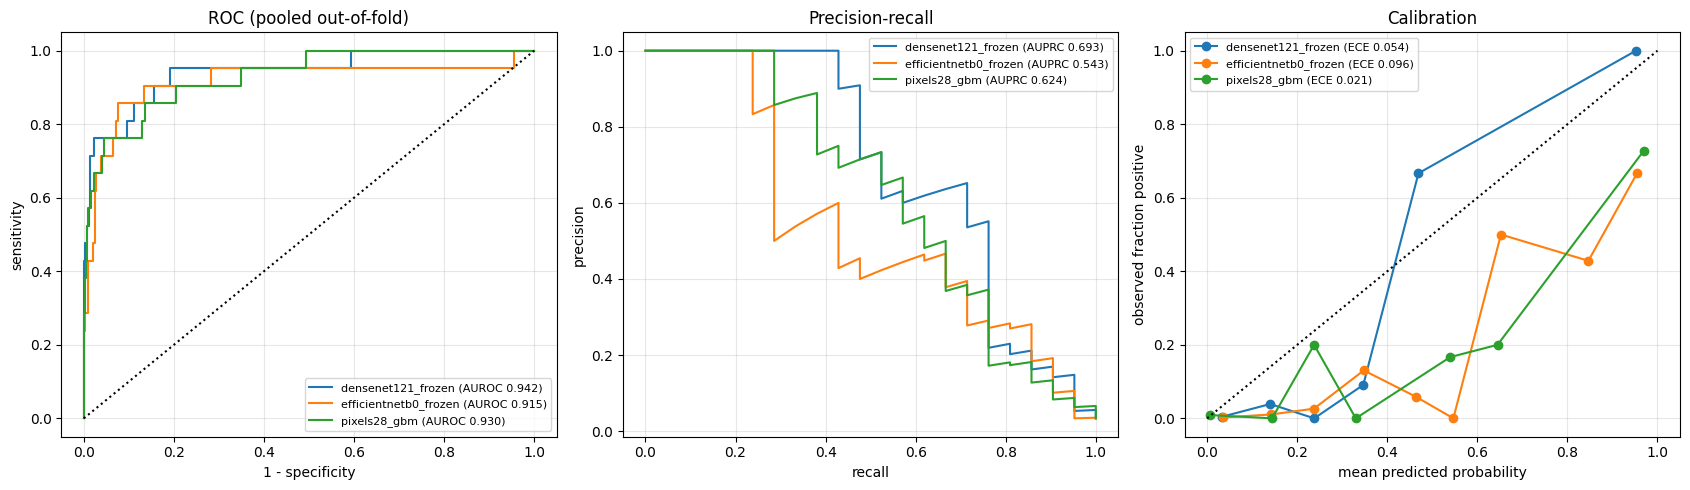

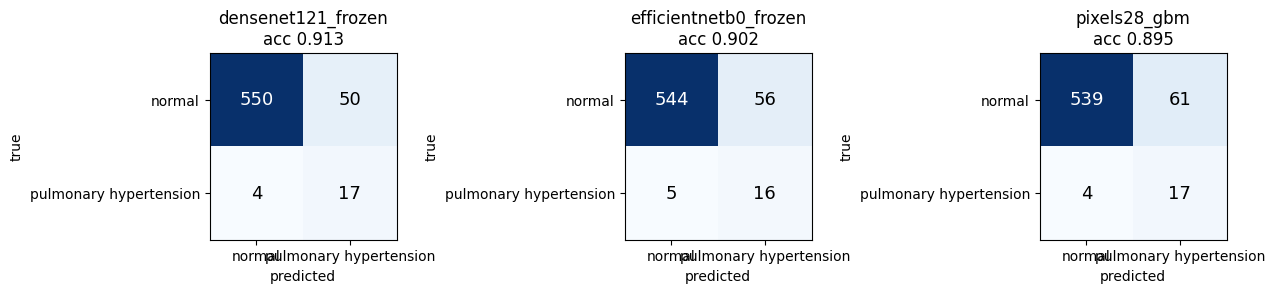

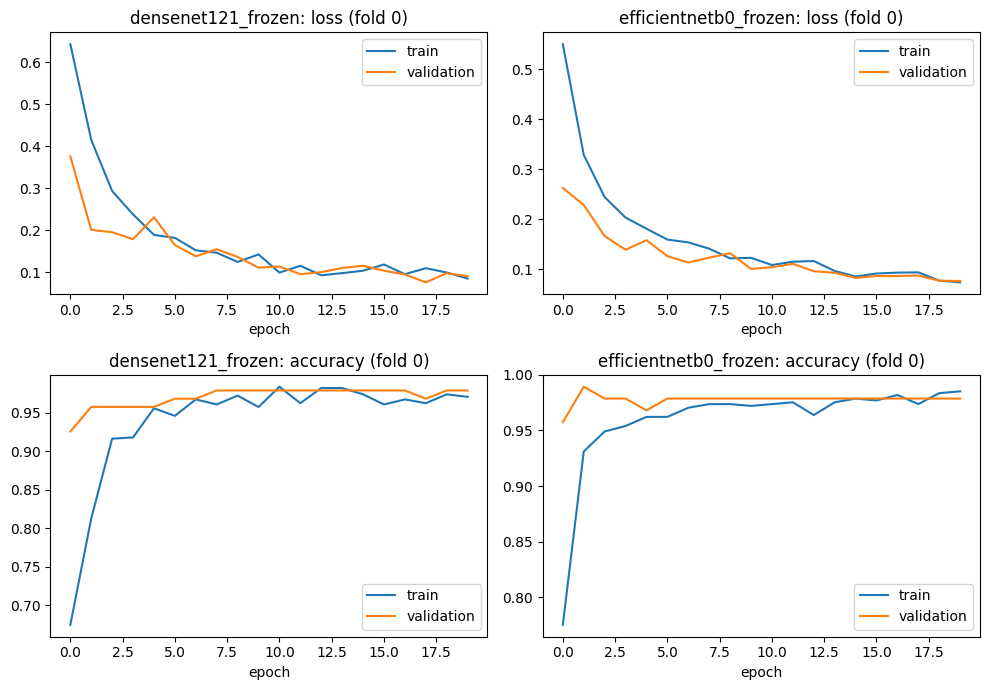

,model,test_AUROC,test_AUROC_ci_low,test_AUROC_ci_high,mean_validation_AUROC,validation_minus_test_AUROC,train_loss,val_loss,loss_gap_val_minus_train,verdict
0,densenet121_frozen,0.941508,0.873190,0.987024,0.975097,0.033589,0.116682,0.092877,-0.023806,no strong sign of overfitting
1,efficientnetb0_frozen,0.915476,0.812534,0.979887,0.955686,0.040210,0.105428,0.143057,0.037629,no strong sign of overfitting
2,pixels28_gbm,0.930159,0.867428,0.978220,0.957859,0.027700,NaN,NaN,NaN,no strong sign of overfitting


In [21]:
make_figures(res, histories)
over = overfitting_check(res, folds_df, histories)
display(over)

### Step 6. Shortcut and format probes

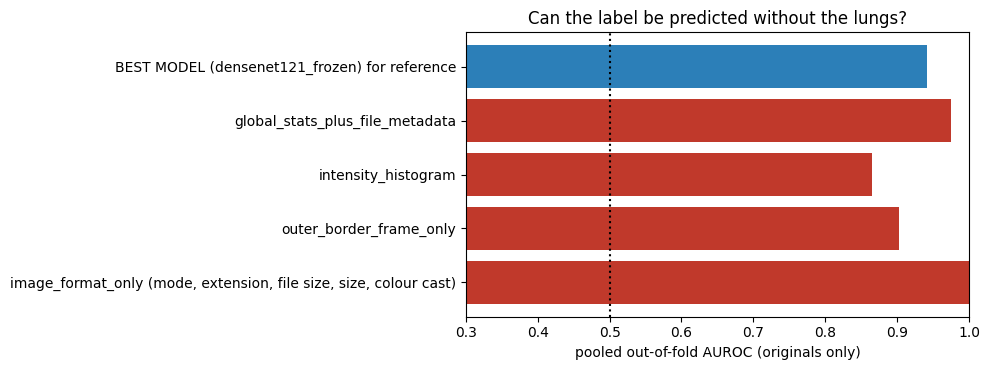

,probe,AUROC,ci_low,ci_high,rule_of_thumb_verdict
0,"image_format_only (mode, extension, file size,...",1.000000,1.000000,1.000000,label is largely predictable without the lungs...
1,outer_border_frame_only,0.902143,0.811793,0.964769,label is largely predictable without the lungs...
2,intensity_histogram,0.865476,0.783748,0.933842,label is largely predictable without the lungs...
3,global_stats_plus_file_metadata,0.975476,0.949174,0.995325,label is largely predictable without the lungs...
4,BEST MODEL (densenet121_frozen) for reference,0.941508,NaN,NaN,


In [22]:
probes = ph_shortcut_probes(df, G64, y, groups, res) if CFG.RUN_PROBES else None
display(probes)

### Step 7. External validation (runs only if EXTERNAL is set)

In [23]:
external = external_validation(df, X, G64, H, y, groups, res)
display(external)

08:11:03 No external dataset configured (CFG.EXTERNAL is None). Skipping.


None

### Step 8. Export everything and print the paper-ready text

In [24]:
ms = export_all(df, X, audit, res, folds_df, probes, None, external)
exact = ph_exact_table(res)
append_ph_snippets(audit, probes, exact, over)
display(ms)
print(open(OUT / "paper_snippets.md").read())

08:11:03 All outputs are in results


,params,pretrained_weights_loaded,mean_epochs,total_seconds
model,,,,
densenet121_frozen,7038529.0,True,17.6,993.0
efficientnetb0_frozen,4050852.0,True,17.9,587.6
pixels28_gbm,NaN,False,NaN,127.9


# Paper-ready text for `folder` (generated by the notebook; check every number before use)

## Dataset and splits

We used 621 images (21 pulmonary hypertension, 600 normal; prevalence 3.4%). 0 exact duplicate files were removed. Near-duplicates were found with a 256-bit difference hash followed by a pixel-correlation check (r >= 0.97): 0 pairs, 200 images in multi-image groups. All images of a group were always kept in the same fold. The dataset provides no patient identifiers, so patient-level separation could not be guaranteed and is listed as a limitation.

## Protocol

Stratified, group-aware 11-fold cross-validation. Inside each training portion about one sixth was held out as a validation set used only for early stopping (patience 5 on validation loss) and for choosing the decision threshold; the test fold was never used for any decision. Class imbalance was handled with class weights; no oversampling was used. Augmentation: small rotation, translation, zoom and contrast changes

## Where each output goes in the paper

| Output (in `results/`) | Use it for |
|---|---|
| `tables/group_report.csv`, `duplicate_audit.json` | Reviewer point 2: how the 22 sources were identified and kept together |
| `tables/table_main_val_youden.csv`, `table_threshold_0.5.csv`, `ph_exact_ci.csv` | PH performance table. Prefer AUROC, PR-AUC and the 0.5-threshold table: the validation set holds only about 3 PH sources, so validation-chosen thresholds are noisy |
| `tables/overfitting_check.csv` | Shows train vs validation gap, validation vs test drop, and distance from chance |
| `figures/confusion_matrices.png`, `learning_curves_fold0.png`, `roc_pr_calibration.png` | Replace the PH figures (do not reuse figures from other diseases) |
| `tables/shortcut_probes.csv`, `figures/shortcut_probes.png` | Reviewer point 5 |
| `tables/models_summary.csv`, `data/config.json`, `data/environment.json`, `data/split_manifest.csv` | Reviewer point 3 |
| `tables/predictions_oof.csv` | Single source of truth for every number and figure |
| `paper_snippets.md` | Draft Methods / Results / Limitations text with real numbers. Check every number |

Download `results_ph.zip` from the Output tab when the run finishes.
